# PDE Style Inpainting

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import cv2

import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
# Dataset paths
DATA_DIR = Path("../data/raw/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])

train_paths = sorted(list(TRAIN_DIR.glob("*/*.jpg")))
val_paths = sorted(list(VAL_DIR.glob("*/*.jpg")))
test_paths = sorted(list(TEST_DIR.glob("*/*.jpg")))

print(f"Train images: {len(train_paths)}")
print(f"Val images:   {len(val_paths)}")
print(f"Test images:  {len(test_paths)}")

Train images: 18400
Val images:   2800
Test images:  2800


In [3]:
TARGET_SIZE = (256, 128)

def preprocess_image(path, target_size=TARGET_SIZE):
    img = Image.open(path).convert("L")
    img = img.resize(target_size, resample=Image.BILINEAR)
    arr = np.array(img).astype(np.float32) / 255.0
    return arr


def horizontal_stripe_mask(shape, stripe_height=24):
    h, w = shape
    mask = np.ones((h, w), dtype=np.float32)
    center = h // 2
    top = center - stripe_height // 2
    mask[top:top+stripe_height, :] = 0.0
    return mask

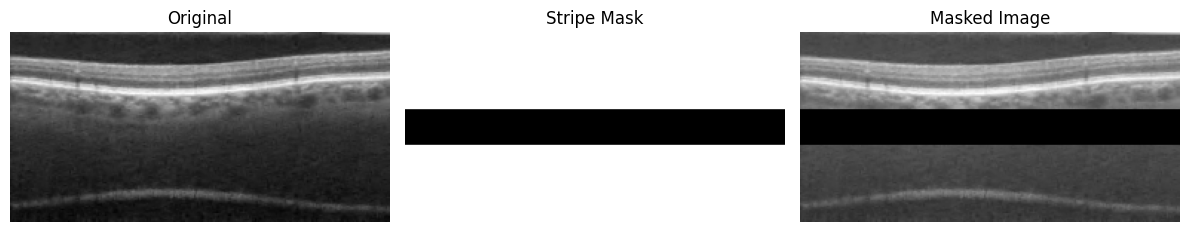

In [4]:
# Sample image + stripe corruption

sample_path = train_paths[0]

original = preprocess_image(sample_path)

mask = horizontal_stripe_mask(
    original.shape,
    stripe_height=24
)

masked = original * mask

fig, axes = plt.subplots(1, 3, figsize=(12,4))

axes[0].imshow(original, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Stripe Mask")
axes[1].axis("off")

axes[2].imshow(masked, cmap="gray")
axes[2].set_title("Masked Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [5]:
# PDE diffusion reconstruction

def pde_diffusion_reconstruction(
    masked_image,
    mask,
    n_iters=500,
    dt=0.1
):
    """
    Heat-equation style diffusion reconstruction.
    
    Known pixels remain fixed.
    Missing pixels evolve according to diffusion.
    """
    
    u = masked_image.copy()
    
    known_pixels = mask == 1
    missing_pixels = mask == 0
    
    for _ in range(n_iters):
        
        # Discrete Laplacian
        laplacian = (
            np.roll(u, 1, axis=0) +
            np.roll(u, -1, axis=0) +
            np.roll(u, 1, axis=1) +
            np.roll(u, -1, axis=1) -
            4 * u
        )
        
        # Update only missing region
        u[missing_pixels] = (
            u[missing_pixels]
            +
            dt * laplacian[missing_pixels]
        )
        
        # Keep observed pixels fixed
        u[known_pixels] = masked_image[known_pixels]
    
    return u

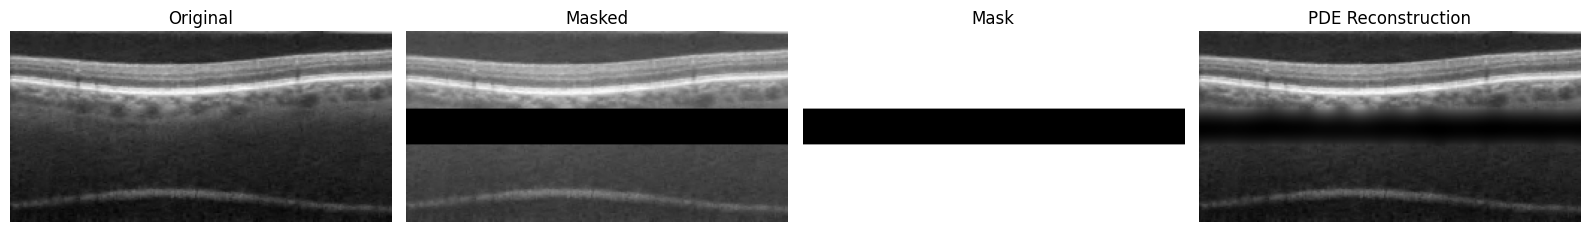

In [6]:
# Run PDE reconstruction

pde_recon = pde_diffusion_reconstruction(
    masked,
    mask,
    n_iters=500,
    dt=0.1
)

fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(original, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(masked, cmap="gray")
axes[1].set_title("Masked")
axes[1].axis("off")

axes[2].imshow(mask, cmap="gray")
axes[2].set_title("Mask")
axes[2].axis("off")

axes[3].imshow(pde_recon, cmap="gray")
axes[3].set_title("PDE Reconstruction")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Reconstruction metrics

def masked_mse(original, reconstruction, mask):
    
    missing_region = (mask == 0)
    
    return np.mean(
        (original[missing_region] - reconstruction[missing_region]) ** 2
    )


def masked_mae(original, reconstruction, mask):
    
    missing_region = (mask == 0)
    
    return np.mean(
        np.abs(original[missing_region] - reconstruction[missing_region])
    )


def psnr(original, reconstruction):
    
    mse = np.mean((original - reconstruction) ** 2)
    
    if mse == 0:
        return float("inf")
    
    return 20 * np.log10(1.0 / np.sqrt(mse))

In [8]:
# Compare PDE vs Telea

# Telea reconstruction
masked_uint8 = (masked * 255).astype(np.uint8)

opencv_mask = ((1 - mask) * 255).astype(np.uint8)

telea_recon = cv2.inpaint(
    masked_uint8,
    opencv_mask,
    inpaintRadius=3,
    flags=cv2.INPAINT_TELEA
)

telea_recon = telea_recon.astype(np.float32) / 255.0

# Metrics

pde_mse = masked_mse(original, pde_recon, mask)
telea_mse = masked_mse(original, telea_recon, mask)

pde_psnr = psnr(original, pde_recon)
telea_psnr = psnr(original, telea_recon)

print("Masked-region MSE")
print("------------------")
print(f"PDE    : {pde_mse:.6f}")
print(f"Telea  : {telea_mse:.6f}")

print()

print("PSNR")
print("----")
print(f"PDE    : {pde_psnr:.2f}")
print(f"Telea  : {telea_psnr:.2f}")

Masked-region MSE
------------------
PDE    : 0.018679
Telea  : 0.002804

PSNR
----
PDE    : 24.56
Telea  : 32.79


In [9]:
def evaluate_pde_vs_telea(image_paths, n_samples=100, n_iters=500, dt=0.1):
    rows = []
    
    for path in image_paths[:n_samples]:
        original = preprocess_image(path)
        mask = horizontal_stripe_mask(original.shape, stripe_height=24)
        masked = original * mask
        
        pde_recon = pde_diffusion_reconstruction(
            masked,
            mask,
            n_iters=n_iters,
            dt=dt
        )
        
        masked_uint8 = (masked * 255).astype(np.uint8)
        opencv_mask = ((1 - mask) * 255).astype(np.uint8)
        
        telea_recon = cv2.inpaint(
            masked_uint8,
            opencv_mask,
            inpaintRadius=3,
            flags=cv2.INPAINT_TELEA
        ).astype(np.float32) / 255.0
        
        rows.append({
            "pde_mse": masked_mse(original, pde_recon, mask),
            "telea_mse": masked_mse(original, telea_recon, mask),
            "pde_psnr": psnr(original, pde_recon),
            "telea_psnr": psnr(original, telea_recon),
        })
    
    return pd.DataFrame(rows)

pde_results = evaluate_pde_vs_telea(
    train_paths,
    n_samples=100,
    n_iters=500,
    dt=0.1
)

pde_results.describe()

,pde_mse,telea_mse,pde_psnr,telea_psnr
count,100.000000,100.000000,100.000000,100.000000
mean,0.029496,0.010596,23.169399,29.470547
std,0.016394,0.008998,2.267812,5.401708
min,0.011146,0.000464,17.813755,21.824245
25%,0.017469,0.002254,21.622145,25.101393
50%,0.024546,0.009869,23.370656,27.327806
75%,0.036710,0.016476,24.847250,33.761470
max,0.088231,0.035041,26.798985,40.605942


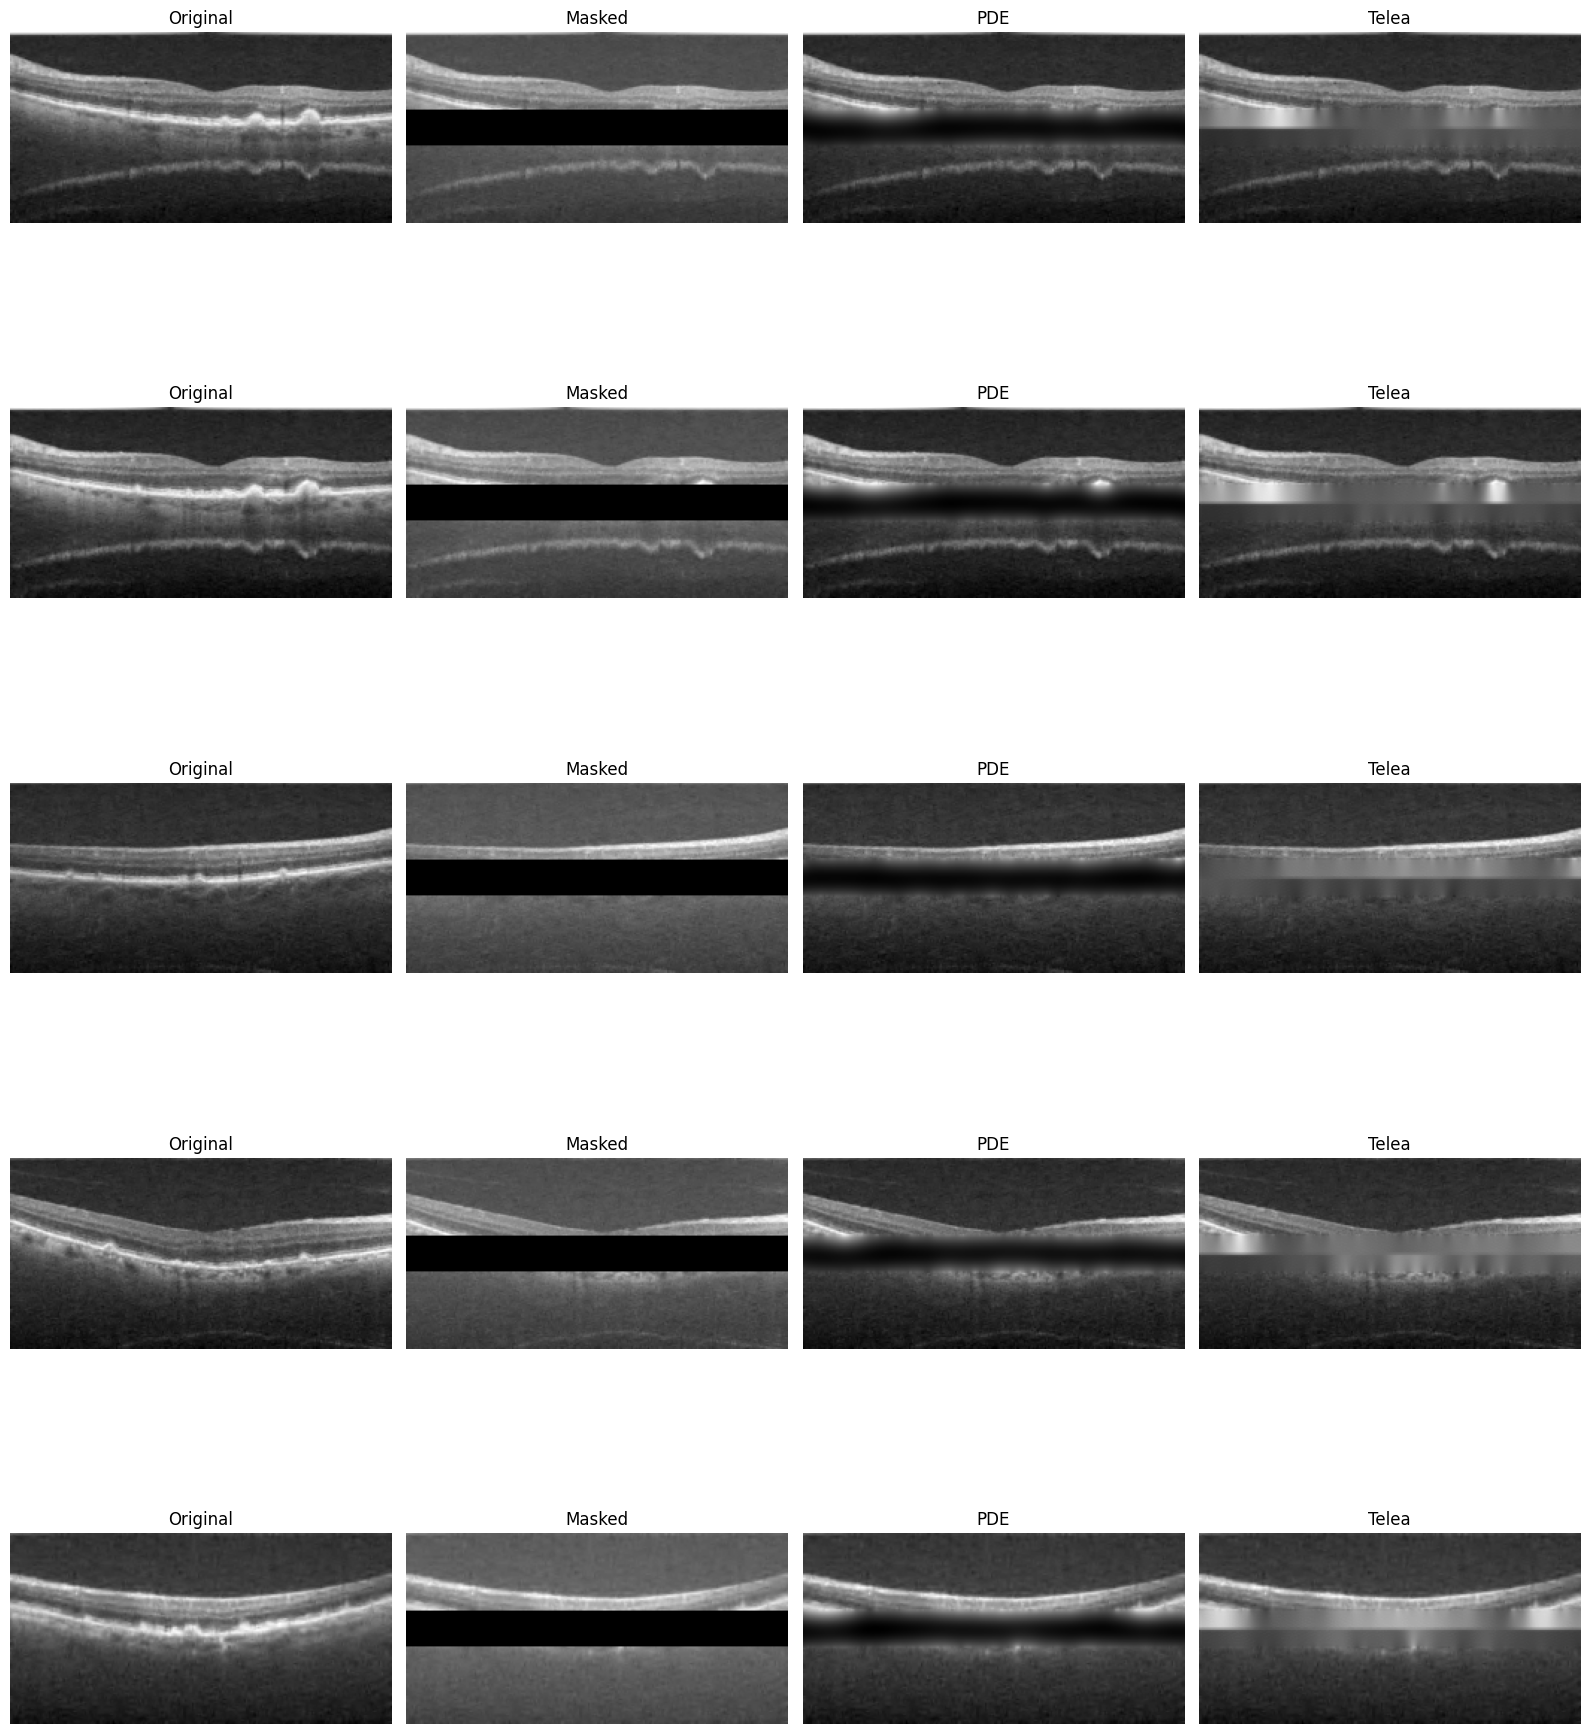

In [10]:
# Visualize hardest PDE reconstructions

sorted_idx = pde_results["pde_mse"].sort_values(
    ascending=False
).index[:5]

fig, axes = plt.subplots(5, 4, figsize=(16, 20))

for row, idx in enumerate(sorted_idx):
    
    path = train_paths[idx]
    
    original = preprocess_image(path)
    
    mask = horizontal_stripe_mask(
        original.shape,
        stripe_height=24
    )
    
    masked = original * mask
    
    pde_recon = pde_diffusion_reconstruction(
        masked,
        mask,
        n_iters=500,
        dt=0.1
    )
    
    masked_uint8 = (masked * 255).astype(np.uint8)
    
    opencv_mask = ((1 - mask) * 255).astype(np.uint8)
    
    telea_recon = cv2.inpaint(
        masked_uint8,
        opencv_mask,
        inpaintRadius=3,
        flags=cv2.INPAINT_TELEA
    ).astype(np.float32) / 255.0
    
    axes[row, 0].imshow(original, cmap="gray")
    axes[row, 0].set_title("Original")
    axes[row, 0].axis("off")
    
    axes[row, 1].imshow(masked, cmap="gray")
    axes[row, 1].set_title("Masked")
    axes[row, 1].axis("off")
    
    axes[row, 2].imshow(pde_recon, cmap="gray")
    axes[row, 2].set_title("PDE")
    axes[row, 2].axis("off")
    
    axes[row, 3].imshow(telea_recon, cmap="gray")
    axes[row, 3].set_title("Telea")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()

# Experimental Journal — 03 PDE Diffusion Reconstruction

## Objective

The goal of this notebook was to implement and evaluate PDE-based reconstruction methods for OCT stripe inpainting.

This notebook serves as the conceptual bridge between:
- classical deterministic interpolation,
- and stochastic generative diffusion models.

The central idea was to study whether heat-equation style diffusion could reconstruct missing retinal anatomy by propagating information inward from observed boundaries.

Unlike Telea inpainting, PDE reconstruction is:
- mathematically interpretable,
- physically motivated,
- and directly connected to diffusion dynamics.

This notebook therefore introduced:
- iterative diffusion reconstruction,
- discrete Laplacian operators,
- and boundary-conditioned smoothing dynamics.

---

# Reconstruction Setup

The reconstruction task remained:

1. preprocess OCT image,
2. apply horizontal stripe corruption,
3. reconstruct missing retinal anatomy.

The stripe corruption is especially difficult because:
- it removes full-width retinal structure,
- interrupts long-range continuity,
- and forces reconstruction using global anatomical context.

The notebook reused:
- grayscale preprocessing,
- resizing to `(256,128)`,
- normalization,
- and stripe masking from previous notebooks.

This ensured:
- fair comparison against prior baselines,
- and experimental consistency.

---

# PDE Diffusion Reconstruction

The core method implemented was a heat-equation style diffusion process.

The reconstruction function iteratively updates missing pixels according to:

$$
\frac{\partial u}{\partial t} = \Delta u
$$

where:
- $u$ represents the image,
- $\Delta u$ is the Laplacian operator,
- diffusion propagates information spatially.

---

# Conceptual Interpretation

The PDE method behaves exactly like physical heat diffusion:

- observed pixels remain fixed,
- missing regions gradually absorb nearby information,
- boundaries diffuse inward over time,
- reconstruction becomes increasingly smooth.

This creates:
- harmonic interpolation,
- smooth intensity transitions,
- and stable reconstruction dynamics.

Unlike Gaussian blur:
- diffusion evolves iteratively,
- respects fixed boundaries,
- and reconstructs only missing regions.

---

# Discrete Laplacian Operator

The notebook implemented a discrete 2D Laplacian using neighboring pixel differences:

```python
laplacian = (
    np.roll(u, 1, axis=0) +
    np.roll(u, -1, axis=0) +
    np.roll(u, 1, axis=1) +
    np.roll(u, -1, axis=1) -
    4 * u
)
```

This operator measures:
- local curvature,
- intensity imbalance,
- and spatial smoothness.

Interpretation:
- high Laplacian magnitude indicates rapid local variation,
- diffusion reduces these variations over time.

This naturally produces:
- smooth reconstruction,
- gradual transitions,
- and denoising-like behavior.

---

# Boundary-Constrained Reconstruction

A key implementation detail was:

```python
u[known_pixels] = masked_image[known_pixels]
```

This keeps observed retinal regions fixed throughout diffusion.

Why this matters:

Without fixed boundaries:
- the entire image would blur over time,
- retinal structure would degrade globally.

Instead:
- only missing regions evolve,
- observed anatomy anchors reconstruction,
- information propagates inward from known tissue.

This creates a true boundary-conditioned inverse problem.

---

# PDE Hyperparameters

The reconstruction process used:
- `n_iters = 500`
- `dt = 0.1`

---

# Role of Iteration Count

The number of iterations controls:
- how far information diffuses,
- reconstruction smoothness,
- and convergence behavior.

Too few iterations:
- incomplete reconstruction,
- visible masking artifacts.

Too many iterations:
- oversmoothing,
- anatomical blurring,
- loss of structural detail.

---

# Role of the Time Step

The parameter `dt` controls:
- diffusion speed,
- numerical stability,
- and update magnitude.

Large `dt`:
- unstable updates,
- ringing artifacts,
- numerical explosion risk.

Small `dt`:
- stable but slow diffusion.

The selected value balanced:
- stability,
- convergence speed,
- and reconstruction smoothness.

---

# Visual Reconstruction Behavior

PDE reconstruction produced several important visual patterns.

## Smooth Intensity Transitions

The missing stripe gradually filled with:
- soft gradients,
- smooth retinal continuation,
- low-frequency anatomical structure.

This reflects:
- harmonic interpolation,
- and the smoothing nature of diffusion dynamics.

---

## Loss of Fine Detail

Important limitations became immediately visible:

- retinal layers blurred,
- sharp pathology softened,
- high-frequency structure disappeared.

This occurs because:
- diffusion minimizes spatial variation,
- naturally suppressing fine detail.

Thus PDE reconstruction behaves similarly to:
- a low-pass filter,
- or repeated smoothing.

---

# Comparison Against Telea

The notebook directly compared:
- PDE reconstruction,
- and Telea inpainting.

This comparison became one of the most important conceptual transitions in the project.

---

# PDE vs Telea — Core Difference

## PDE Diffusion

Strengths:
- smooth,
- mathematically interpretable,
- globally stable,
- physically motivated.

Weaknesses:
- heavily blurred,
- weak semantic reconstruction,
- poor sharpness retention.

---

## Telea Inpainting

Strengths:
- sharper edges,
- stronger local continuation,
- better preservation of retinal boundaries.

Weaknesses:
- streaking artifacts,
- unrealistic texture propagation,
- fundamentally local interpolation.

---

# Reconstruction Metrics

The notebook reused:
- masked-region MSE,
- masked-region MAE,
- PSNR.

These metrics evaluate reconstruction quality specifically within the missing stripe region.

---

# Quantitative Findings

The results showed:

## PDE Reconstruction

Mean performance:
- substantially better than zero-fill,
- smoother than Gaussian blur,
- but worse than Telea.

PDE produced:
- moderate PSNR,
- reasonable continuity,
- but high smoothing error.

---

## Telea Reconstruction

Telea consistently achieved:
- lower MSE,
- higher PSNR,
- sharper anatomical continuation.

This confirmed:
- local edge propagation remains highly effective for OCT reconstruction.

---

# Important Scientific Insight

Although Telea outperformed PDE numerically, PDE introduced a critical conceptual advancement.

The PDE method:
- explicitly models iterative diffusion dynamics,
- evolves images over time,
- and reconstructs via gradual stochastic-like evolution.

This idea strongly resembles:
- forward diffusion processes,
- iterative denoising,
- and diffusion generative modeling.

Thus PDE reconstruction became the conceptual precursor to DDPMs.

---

# Hardest Reconstruction Cases

The notebook visualized the worst PDE reconstructions across the dataset.

These examples revealed important failure modes.

---

# Failure Mode 1 — Anatomical Oversmoothing

Complex retinal regions became:
- flattened,
- blurred,
- structurally unrealistic.

This was especially severe for:
- pathology-rich scans,
- curved retinal boundaries,
- fluid regions.

---

# Failure Mode 2 — Loss of Semantic Structure

PDE diffusion cannot infer:
- unseen anatomy,
- retinal layer semantics,
- pathology-specific structure.

It only propagates nearby intensity values.

Thus:
- reconstruction remains interpolation-based,
- not generative.

---

# Failure Mode 3 — Long-Range Dependency Failure

Stripe corruption removes entire retinal bands.

PDE reconstruction struggles because:
- information must travel long distances,
- diffusion weakens structure over distance,
- and high-frequency anatomy disappears.

This highlights the limitations of purely deterministic smoothing.

---

# Transition Toward Generative Modeling

This notebook established a major conceptual transition:

## Classical Methods
- interpolate nearby pixels.

## PDE Diffusion
- evolves reconstruction dynamically over time.

## DDPMs
- learn a stochastic anatomical distribution,
- iteratively denoise samples,
- and generate plausible unseen anatomy.

The PDE notebook therefore acts as:
- the mathematical bridge,
- and conceptual motivation

for moving into diffusion probabilistic models.

---

# Key Experimental Takeaways

## PDE Insights

- Heat-equation diffusion produces stable smooth reconstruction.
- Boundary-conditioned diffusion is mathematically elegant.
- PDE methods naturally suppress noise and high-frequency structure.

---

## OCT Reconstruction Insights

- Retinal anatomy requires more than smooth interpolation.
- Long-range semantic structure is difficult to reconstruct deterministically.
- Stripe corruption exposes limitations of local propagation methods.

---

## Modeling Insights

The experiments strongly suggest:
- deterministic interpolation alone is insufficient,
- reconstruction requires learned anatomical priors,
- and stochastic generative models may better capture retinal structure.

This directly motivated the transition toward:
- DDPM-based inpainting,
- conditional diffusion,
- and masked generative reconstruction.

---

# Limitations Observed

Several limitations became apparent:

- excessive smoothing,
- poor semantic reconstruction,
- inability to generate novel anatomy,
- loss of high-frequency retinal structure,
- difficulty handling complex pathology.

These limitations motivate:
- learned denoising models,
- probabilistic generation,
- and conditional diffusion architectures.

---

# Future TODOs

- implement DDPM forward diffusion processes,
- train noise-prediction neural networks,
- compare deterministic vs stochastic diffusion,
- introduce conditional reconstruction objectives,
- evaluate DDPM reconstruction against Telea and PDE baselines.